In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [372]:
# Problem 1:

df = pd.read_csv('titanic_data_updated.csv')
df.shape

(891, 12)

In [373]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [374]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
558,559,yes,first,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
114,115,no,third,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
12,13,no,third,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
765,766,yes,first,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0,1,0,13502,77.9583,D11,S
353,354,no,third,"Arnold-Franchi, Mr. Josef",male,25.0,1,0,349237,17.8000,NaN,S


In [ ]:
# Problem 2:

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [376]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [377]:
# Problem 3:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    str    
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(3), str(7)
memory usage: 125.5 KB


In [378]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


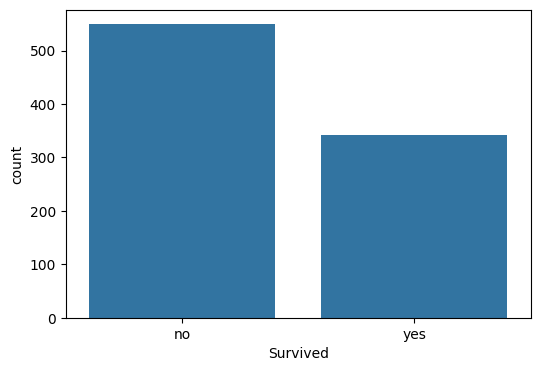

In [379]:
# Problem 4:

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
percentage = df['Survived'].value_counts(normalize=True) * 100

plt.show()

In [380]:
percentage

Survived
no     61.616162
yes    38.383838
Name: proportion, dtype: float64

<Axes: >

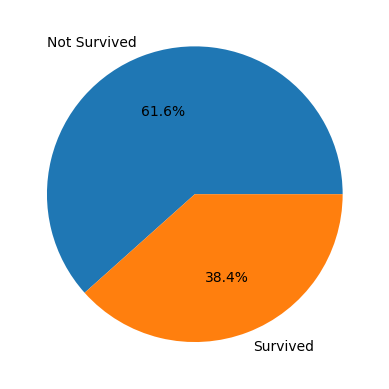

In [381]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Not Survived', 'Survived'])

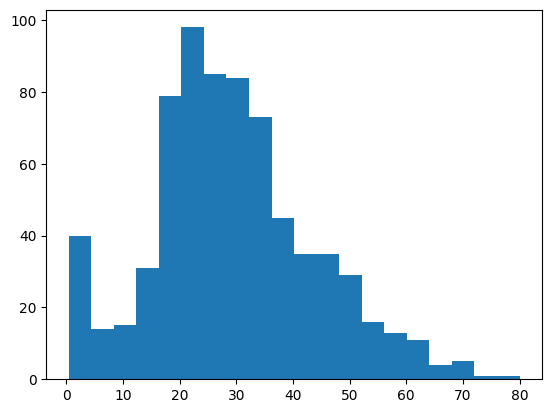

In [382]:
# Problem 5:

plt.hist(df['Age'], bins=20); plt.show()

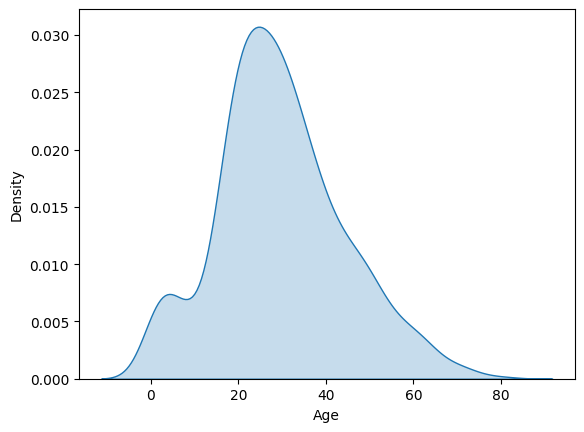

In [383]:
sns.kdeplot(df['Age'], fill=True); plt.show()

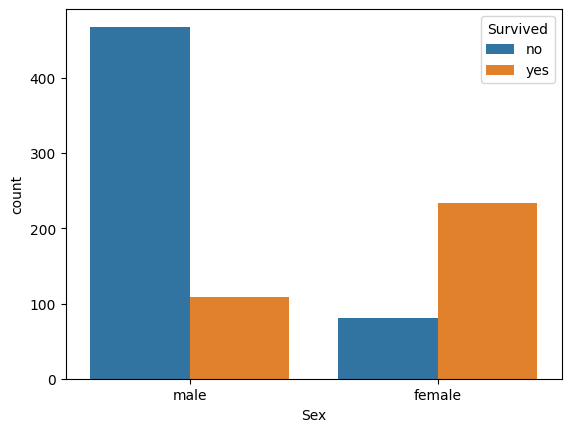

In [384]:
# Problem 6:

sns.countplot(x='Sex', hue='Survived', data=df); plt.show()

In [385]:
df.groupby('Sex')['Survived'].value_counts(normalize=True)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64

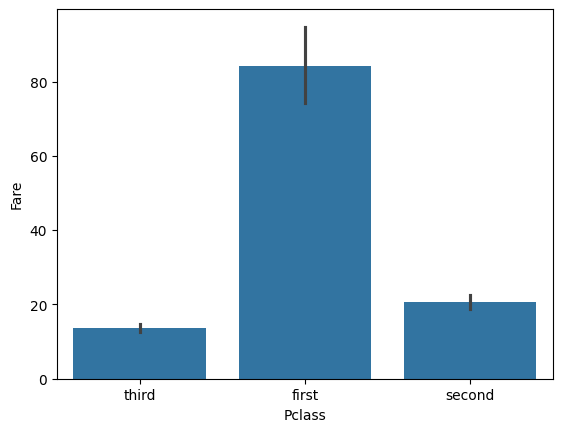

In [386]:
# Problem 7:

sns.barplot(x='Pclass', y='Fare', data=df); plt.show()

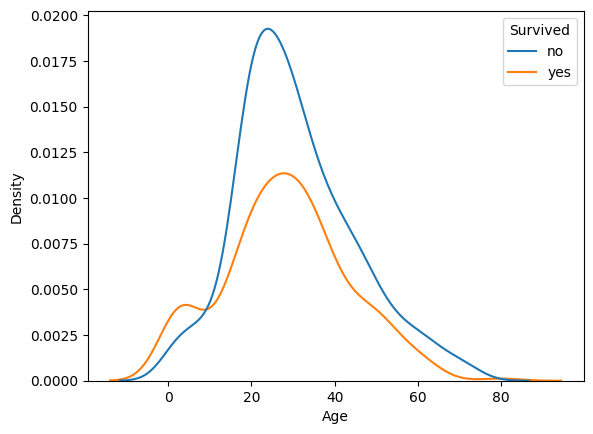

In [387]:
# Problem 8:

sns.kdeplot(data=df, x='Age', hue='Survived'); plt.show()

In [388]:
df = pd.read_csv('titanic_data_updated.csv')
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [389]:
# Problem 9:

df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='str')

In [390]:
# Separate features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
display(X_train.shape)

(712, 8)

In [391]:
X_test.shape

(179, 8)

In [392]:
y_train.shape

(712,)

In [393]:
# Problem 10:

age_imputer = SimpleImputer(strategy='mean')
df['Age'] = age_imputer.fit_transform(df[['Age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = embarked_imputer.fit_transform(df[['Embarked']]).ravel()

cabin_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
df['Cabin'] = cabin_imputer.fit_transform(df[['Cabin']]).ravel()
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64